import pandas as pd


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [43]:
orders = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Orders', header = 1)
campaign_data = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Campaign Data')
order_process_data = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Order Process Data')
intern_data_study = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='InternData Study')




In [8]:
# Check the 'Intern Data Study' File

intern_data_study.shape # 290 rows, 3 columns

(290, 3)

In [9]:
# ready to ship and Pickup Date are datetime and Ordr Id is object
intern_data_study.dtypes

Order ID                      object
Ready to Ship Date    datetime64[ns]
Pickup Date           datetime64[ns]
dtype: object

In [10]:
intern_data_study.describe()

,Ready to Ship Date,Pickup Date
count,290,290
mean,2020-06-18 15:08:41.379310336,2020-06-20 06:47:10.344827648
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


In [11]:
# there are 86 duplicated rows in the dataset
# delete duplicates
intern_data_study.duplicated().sum()

np.int64(86)

In [12]:
# there are 86 duplicated rows in Order ID
intern_data_study['Order ID'].duplicated().sum()

np.int64(86)

In [13]:
# latest Pickup date in the dataset
max_date_pickup = intern_data_study['Pickup Date'].max()
max_date_pickup

Timestamp('2020-12-09 00:00:00')

In [14]:
# earliest Pickup date in the dataset
min_date_pickup = intern_data_study['Pickup Date'].min()
min_date_pickup

Timestamp('2019-09-03 00:00:00')

In [15]:
# 463 days timespan
time_differnce = max_date_pickup - min_date_pickup
time_differnce

Timedelta('463 days 00:00:00')

In [16]:
# calculate delivery time in days between ready to ship and pickup; make it more accurate and use hours?

intern_data_study['time_at_logistic_center'] = intern_data_study['Pickup Date'] - intern_data_study['Ready to Ship Date']
intern_data_study['time_at_logistic_center']

0     1 days
1     1 days
2     0 days
3     0 days
4     1 days
       ...  
285   3 days
286   3 days
287   3 days
288   3 days
289   2 days
Name: time_at_logistic_center, Length: 290, dtype: timedelta64[ns]

In [17]:
# create updated dataset with delivery time column
intern_data_study.to_excel('updated_intern_data_study.xlsx', index=False)

In [18]:
# how many orders per year
intern_data_study['Month-Year'] = intern_data_study['Pickup Date'].dt.to_period('M')
orders_per_month = intern_data_study.groupby('Month-Year')['Order ID'].count()
orders_per_month

Month-Year
2019-09     93
2019-10     10
2020-11    155
2020-12     32
Freq: M, Name: Order ID, dtype: int64

In [19]:
intern_data_study['Month-Year'].value_counts()

Month-Year
2020-11    155
2019-09     93
2020-12     32
2019-10     10
Freq: M, Name: count, dtype: int64

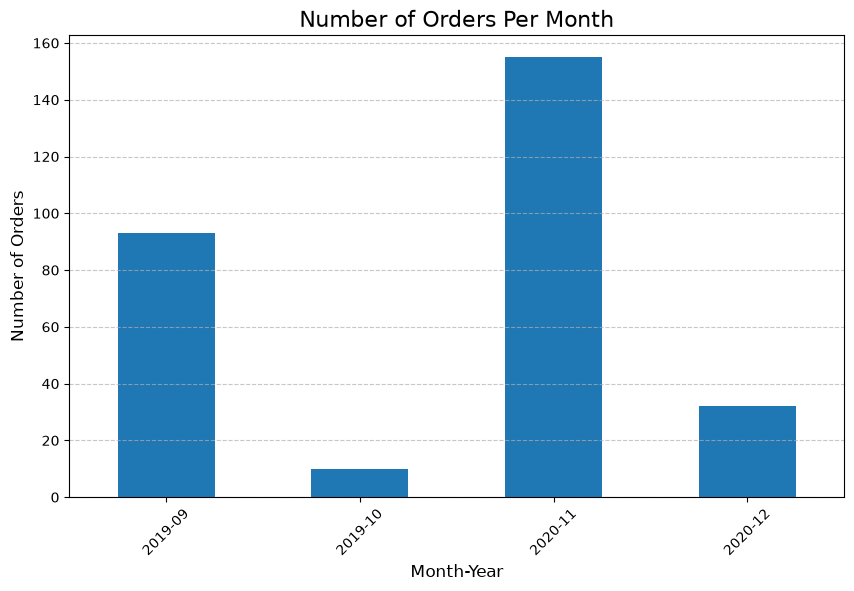

In [20]:
orders_per_month.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Orders Per Month', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

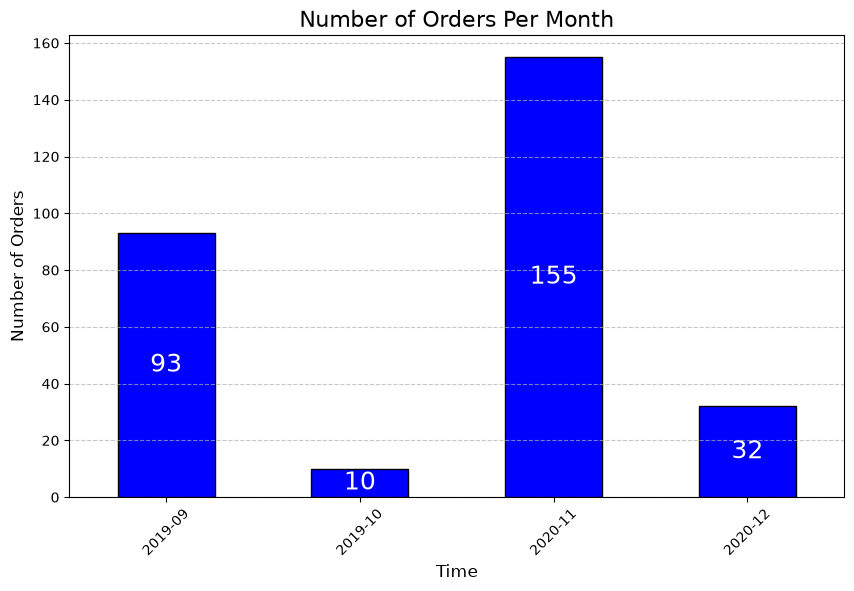

In [27]:
# Plot the bar chart
orders_per_month.plot(kind='bar', figsize=(10, 6), color='blue', edgecolor='black')

# Add labels and title
plt.title('Number of Orders Per Month', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact counts inside the bars
for index, value in enumerate(orders_per_month):
    plt.text(index, value / 2, str(value), ha='center', va='center', fontsize=18, color='white')

# Show the plot
plt.show()

In [35]:
order_process_data['process_time'] = order_process_data['On Truck Scan Date'] - order_process_data['Order Date']
process_time_by_ship_mode = order_process_data.groupby('Ship Mode')['process_time']
mean_process_time = process_time_by_ship_mode.mean()
median_process_time = process_time_by_ship_mode.median()
median_process_time


Ship Mode
Express               3 days
Standard Processing   7 days
Name: process_time, dtype: timedelta64[ns]

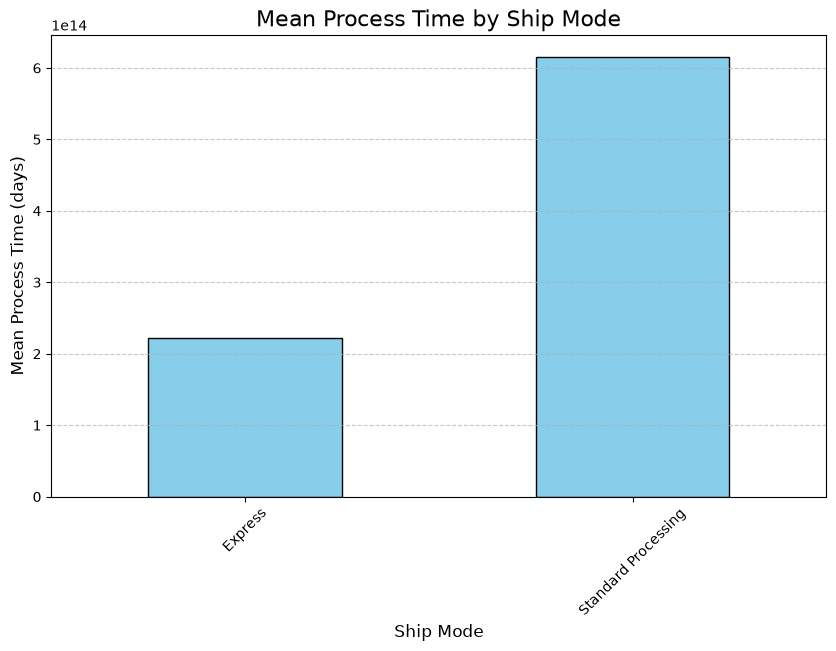

In [34]:
# Plot the mean process time for each Ship Mode
mean_process_time.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Mean Process Time by Ship Mode', fontsize=16)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Mean Process Time (days)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)



plt.show()

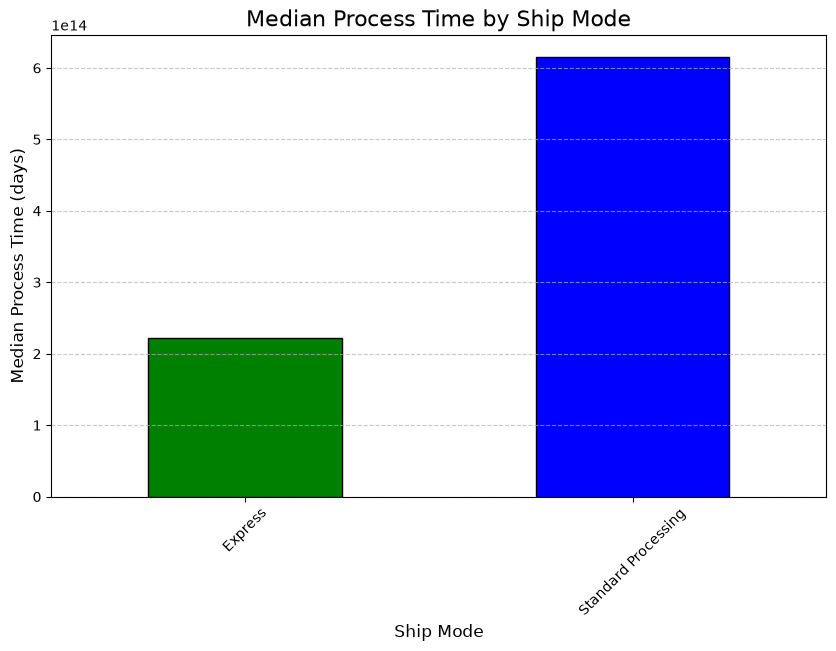

In [38]:

# Plot the median process time for each Ship Mode
colors = ['green' if mode == 'Express' else 'blue' for mode in mean_process_time.index]
mean_process_time.plot(kind='bar', figsize=(10, 6), color=colors, edgecolor='black')

# Add labels and title
plt.title('Median Process Time by Ship Mode', fontsize=16)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Median Process Time (days)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)



plt.show()

In [50]:
order_process_data.sort_values('Order ID')
order_process_data.head(30)

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
5,8606,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
6,9494,CA-2019-105207,2019-01-03,2019-01-09,Standard Processing
7,9495,CA-2019-105207,2019-01-03,2019-01-09,Standard Processing
8,5868,CA-2019-158211,2019-01-04,2019-01-09,Standard Processing
9,5869,CA-2019-158211,2019-01-04,2019-01-09,Standard Processing


In [49]:
orders = orders.sort_values(by='Order ID')
orders.head(30)

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
3742,2718,CA-2017-100006,2017-09-07,Standard Class,DK-13375,Dennis Kane,Email,United States,New York City,New York,10024.0,East,Special Projects Muesil,Only Oats,TEC-PH-10002075,377.970,3,0.0,109.6113
6507,6289,CA-2017-100090,2017-07-08,Standard Class,EB-13705,Ed Braxton,Sales,United States,San Francisco,California,94122.0,West,Power Muesli,Super Fibre Boost,OFF-BI-10001597,196.704,6,0.2,68.8464
8069,6288,CA-2017-100090,2017-07-08,Standard Class,EB-13705,Ed Braxton,Sales,United States,San Francisco,California,94122.0,West,Toasted Muesli,Sweetened,FUR-TA-10003715,502.488,3,0.2,-87.9354
3427,9515,CA-2017-100293,2017-03-14,Standard Class,NF-18475,Neil Französisch,Facebook,United States,Jacksonville,Florida,32216.0,South,Power Muesli,Nuts and more,OFF-PA-10000176,91.056,6,0.2,31.8696
6017,3084,CA-2017-100328,2017-01-28,Standard Class,JC-15340,Jasper Cacioppo,Email,United States,New York City,New York,10024.0,East,Power Muesli,Super Fibre Boost,OFF-BI-10000343,3.928,1,0.2,1.3257
2644,3837,CA-2017-100363,2017-04-08,Standard Class,JM-15655,Jim Mitchum,Sales,United States,Glendale,Arizona,85301.0,West,Power Muesli,Nuts and more,OFF-PA-10004733,19.008,3,0.2,6.8904
1173,3836,CA-2017-100363,2017-04-08,Standard Class,JM-15655,Jim Mitchum,Sales,United States,Glendale,Arizona,85301.0,West,Power Muesli,Maple Sweetened,OFF-FA-10000611,2.368,2,0.2,0.8288
3416,9441,CA-2017-100391,2017-05-25,Standard Class,BW-11065,Barry Weirich,Email,United States,New York City,New York,10035.0,East,Power Muesli,Nuts and more,OFF-PA-10001471,14.620,2,0.0,6.7252
4635,6571,CA-2017-100678,2017-04-18,Standard Class,KM-16720,Kunst Miller,Email,United States,Houston,Texas,77095.0,Central,Power Muesli,Power Clean Fibre Boost,OFF-EN-10000056,149.352,3,0.2,50.4063
499,6572,CA-2017-100678,2017-04-18,Standard Class,KM-16720,Kunst Miller,Email,United States,Houston,Texas,77095.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000474,227.976,3,0.2,28.4970


In [51]:
orders.shape

(9994, 19)

In [53]:
orders.duplicated().sum()

np.int64(0)

In [55]:
ship_mode_counts = orders['Ship Mode'].value_counts()

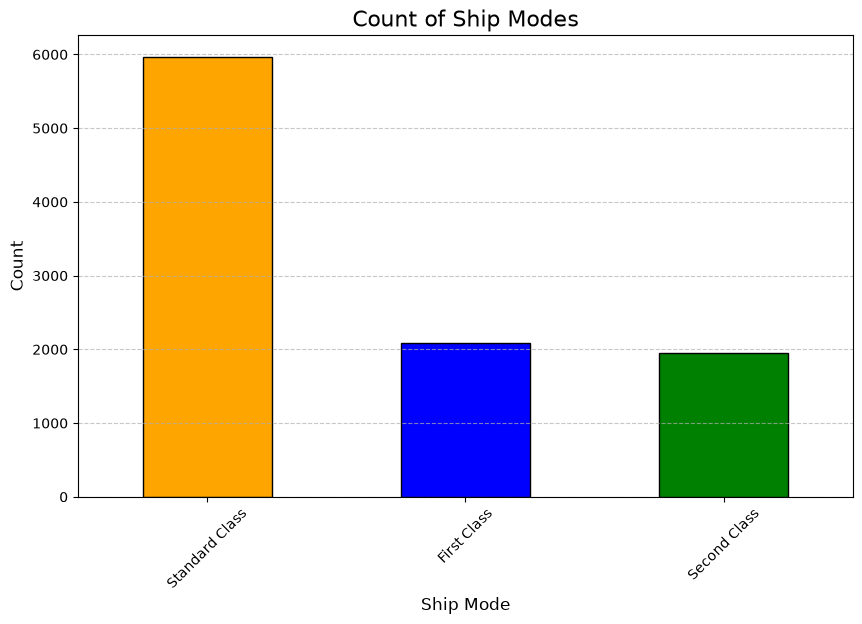

In [61]:
colors = ['green' if mode == 'Second Class' else 'blue' if mode == 'First Class' else 'orange' for mode in ship_mode_counts.index]
ship_mode_counts.plot(kind='bar', figsize=(10, 6), color=colors, edgecolor='black')

# Add labels and title
plt.title('Count of Ship Modes', fontsize=16)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

In [62]:
orders['Country/Region'].value_counts()

Country/Region
United States    9994
Name: count, dtype: int64

In [63]:
orders['State'].value_counts()

State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Virginia                 224
Arizona                  224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Oklahoma                  66
Missouri                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 42
Nevada  

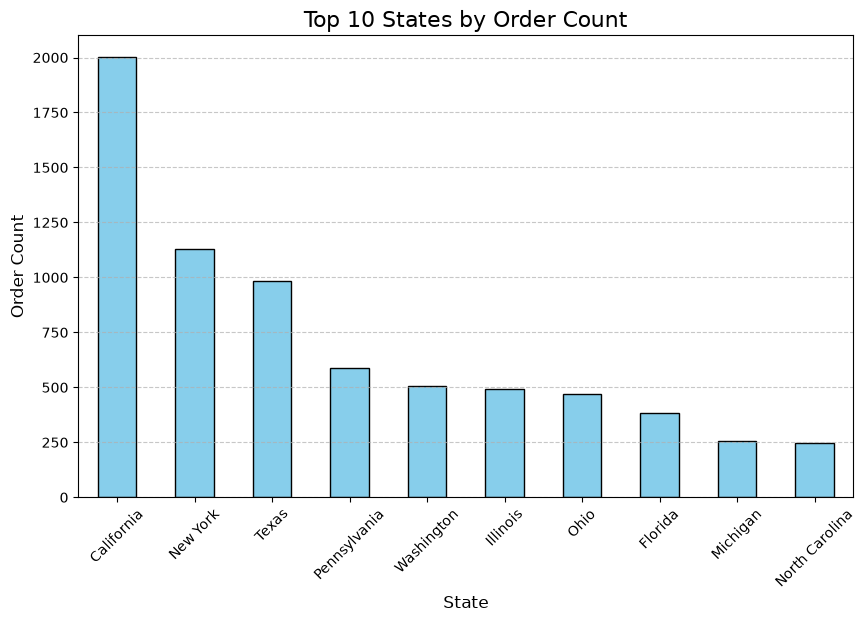

In [64]:
top_10_states = orders['State'].value_counts().head(10)

# Plot the top 10 states as a bar chart
top_10_states.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Top 10 States by Order Count', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [65]:
order_process_data['Ship Mode'].value_counts()


Ship Mode
Standard Processing    4596
Express                1303
Name: count, dtype: int64

In [91]:
transport_time = campaign_data.merge(order_process_data, on='Order ID', how='left')
transport_time.head(10)
transport_time.shape

transport_time.head(10)


,Order ID,Arrival Scan Date,Customer Name,Row ID,Order Date,On Truck Scan Date,Ship Mode,Transportation_time
0,CA-2019-109666,2019-05-03,Kunst Miller,7108,2019-04-19,2019-04-29,Standard Processing,10 days
1,CA-2019-109666,2019-05-03,Kunst Miller,7109,2019-04-19,2019-04-29,Standard Processing,10 days
2,CA-2019-109666,2019-05-03,Kunst Miller,7110,2019-04-19,2019-04-29,Standard Processing,10 days
3,CA-2019-109666,2019-05-03,Kunst Miller,7111,2019-04-19,2019-04-29,Standard Processing,10 days
4,CA-2019-109666,2019-05-03,Kunst Miller,7112,2019-04-19,2019-04-29,Standard Processing,10 days
5,CA-2019-109666,2019-05-03,Kunst Miller,7113,2019-04-19,2019-04-29,Standard Processing,10 days
6,CA-2019-109666,2019-05-03,Kunst Miller,7114,2019-04-19,2019-04-29,Standard Processing,10 days
7,CA-2019-138933,2019-05-03,Jack Lebron,3235,2019-04-24,2019-04-29,Express,5 days
8,CA-2019-130001,2019-05-03,Heather Kirkland,359,2019-04-23,2019-05-01,Standard Processing,8 days
9,CA-2019-113061,2019-05-06,Ed Ludwig,1037,2019-04-22,2019-04-29,Standard Processing,7 days


In [93]:
transport_time['Transportation_time_right'] = transport_time['Arrival Scan Date'] - transport_time['On Truck Scan Date']
transport_time['Transportation_time_right'].mean()

Timedelta('4 days 13:28:22.994011976')

In [95]:
mean_transportation_time = transport_time.groupby('Ship Mode')['Transportation_time_right'].mean()
mean_transportation_time

Ship Mode
Express               4 days 14:06:29.189189189
Standard Processing   4 days 13:17:32.307692307
Name: Transportation_time_right, dtype: timedelta64[ns]